
# DNA Sequence Classification using K-mer Tokenization and LSTM 🧬

## 📌 Project Overview

This project focuses on **DNA sequence classification** using **K-mer tokenization** and a **Bidirectional LSTM-based deep learning model**.

Initially, the goal was to **fine-tune DNA-BERT**, a transformer model pre-trained specifically on DNA sequences. DNA-BERT uses **K-mer tokenization** during pretraining, which makes it highly suitable for genomic tasks.

However, due to **technical issues and errors while loading the DNA-BERT model from Hugging Face**, the approach was adapted to use a **custom LSTM-based architecture**, while still **retaining the K-mer tokenization strategy inspired by the DNA-BERT research paper**.

Despite limited data and computational constraints, the model achieved **reasonable performance**, demonstrating the effectiveness of K-mer representations even with simpler architectures.

---

## 🎯 Objectives

* Understand **K-mer tokenization** for DNA sequences
* Explore ideas from the **DNA-BERT research paper**
* Implement a **sequence classification model** using LSTM
* Handle limited dataset scenarios
* Evaluate model performance on test data

---

## 🧠 Background: DNA-BERT & K-mer Tokenization

DNA-BERT is a transformer-based model pre-trained on large-scale DNA data.
Key idea from the paper:

* DNA sequences are split into overlapping **K-mers** (e.g., 3-mer, 6-mer)
* Each K-mer is treated like a “word” in NLP
* This allows language models to learn biological patterns

📖 **Insight adopted from DNA-BERT**:
Although the transformer model could not be used directly, **K-mer tokenization was retained** and used as input to an LSTM model.

---

## ❌ Why DNA-BERT Was Not Used Directly

* Encountered **Hugging Face loading / compatibility errors**
* Limited environment and compute resources
* Focus shifted from model complexity to **conceptual understanding**

➡️ Final decision:
Use **LSTM with K-mer tokenization** to validate the idea with a simpler, stable architecture.

---

## 🔄 Methodology

1. **DNA sequences preprocessing**
2. **K-mer tokenization** (sliding window over sequences)
3. **Integer encoding of K-mers**
4. **Embedding layer**
5. **Bidirectional LSTM**
6. **Dense layers for classification**
7. **Model evaluation on test data**

---

## 🧪 Model Architecture

```
Model: Sequential
```

| Layer               | Description                        |
| ------------------- | ---------------------------------- |
| Embedding           | Learns dense K-mer representations |
| Bidirectional LSTM  | Captures sequential dependencies   |
| Dropout             | Prevents overfitting               |
| Dense + LeakyReLU   | Feature transformation             |
| Batch Normalization | Stabilizes training                |
| Output Dense Layer  | Multi-class classification         |

### 📊 Model Summary

```
Total Parameters: 843,015
Trainable Parameters: 842,759
Non-trainable Parameters: 256
Model Size: ~3.22 MB
```

---

## 📈 Results

* **Test Accuracy:** `0.6691`
* **Evaluation Time:** `5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 696ms/step`
* Dataset size: **Limited**

📌 Given the **small dataset and absence of large-scale pretraining**, this accuracy is considered **reasonable and informative** for exploratory research.

---

## 🛠️ Technologies Used

* **Python**
* **TensorFlow / Keras**
* **NumPy**
* **K-mer Tokenization**
* **Bidirectional LSTM**

---

## 📌 Key Learnings

* Importance of **K-mer tokenization** in genomics
* How ideas from transformer-based research can be adapted
* Effectiveness of LSTM for biological sequence data
* Practical limitations of large pretrained models
* Working with limited biological datasets

---

## 🔮 Future Improvements

* Successfully integrate **DNA-BERT fine-tuning**
* Use larger and more diverse DNA datasets
* Experiment with different K values
* Compare LSTM vs Transformer performance
* Add biological interpretation of learned features

---

## 📚 Conclusion

This project demonstrates a **practical and adaptive approach** to DNA sequence classification.
Even though DNA-BERT could not be directly used, the **core idea of K-mer tokenization** was successfully applied using an **LSTM-based model**, achieving promising results under limited resources.

---


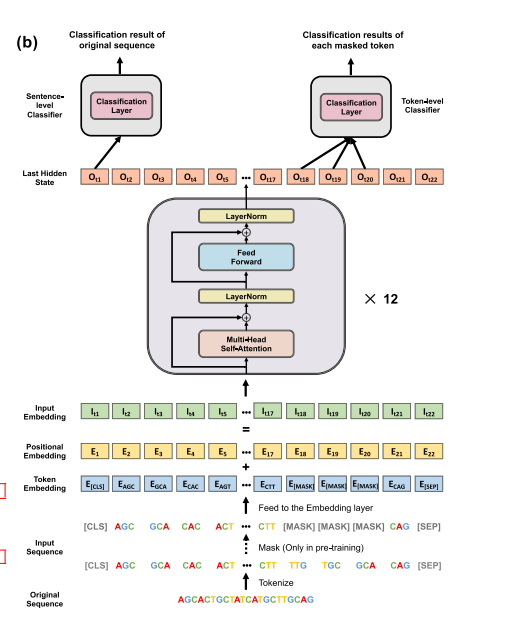

In [ ]:
import pandas as pd

file_path = r"/kaggle/input/dna-sequence-dataset/chimpanzee.txt"


df = pd.read_csv(file_path, sep=r"\s+")

df.columns = ["sequence", "label"]

print(df.head())
print(df.shape)


                                            sequence  label
0  ATGCCCCAACTAAATACCGCCGTATGACCCACCATAATTACCCCCA...      4
1  ATGAACGAAAATCTATTCGCTTCATTCGCTGCCCCCACAATCCTAG...      4
2  ATGGCCTCGCGCTGGTGGCGGTGGCGACGCGGCTGCTCCTGGAGGC...      4
3  ATGGCCTCGCGCTGGTGGCGGTGGCGACGCGGCTGCTCCTGGAGGC...      4
4  ATGGGCAGCGCCAGCCCGGGTCTGAGCAGCGTGTCCCCCAGCCACC...      6
(1682, 2)


In [ ]:
import pandas as pd

file_path = r"/kaggle/input/dna-sequence-dataset/human.txt"


human_df = pd.read_csv(file_path, sep=r"\s+")

human_df.columns = ["sequence", "label"]

print(human_df.head())
print(human_df.shape)


                                            sequence  label
0  ATGCCCCAACTAAATACTACCGTATGGCCCACCATAATTACCCCCA...      4
1  ATGAACGAAAATCTGTTCGCTTCATTCATTGCCCCCACAATCCTAG...      4
2  ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...      3
3  ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...      3
4  ATGCAACAGCATTTTGAATTTGAATACCAGACCAAAGTGGATGGTG...      3
(4380, 2)


In [ ]:
import pandas as pd

file_path = r"/kaggle/input/dna-sequence-dataset/dog.txt"


df = pd.read_csv(file_path, sep=r"\s+")

df.columns = ["sequence", "label"]

print(df.head())
print(df.shape)


                                            sequence  label
0  ATGCCACAGCTAGATACATCCACCTGATTTATTATAATCTTTTCAA...      4
1  ATGAACGAAAATCTATTCGCTTCTTTCGCTGCCCCCTCAATAATAG...      4
2  ATGGAAACACCCTTCTACGGCGATGAGGCGCTGAGCGGCCTGGGCG...      6
3  ATGTGCACTAAAATGGAACAGCCCTTCTACCACGACGACTCATACG...      6
4  ATGAGCCGGCAGCTAAACAGAAGCCAGAACTGCTCCTTCAGTGACG...      0
(820, 2)


Human DNA sequence has maximum data.
Hence it will be chosen.

START FROM HERE

In [ ]:
from google.colab import drive
import pandas as pd
import os

drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/DNA_Dataset/human_dna_data.csv'


human_df = pd.read_csv(file_path)

print("DataFrame loaded successfully.")
print(human_df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DataFrame loaded successfully.
                                            sequence  label  sequence_length  \
0  ATGCCCCAACTAAATACTACCGTATGGCCCACCATAATTACCCCCA...      4              207   
1  ATGAACGAAAATCTGTTCGCTTCATTCATTGCCCCCACAATCCTAG...      4              681   
2  ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...      3             1686   
3  ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...      3             1206   
4  ATGCAACAGCATTTTGAATTTGAATACCAGACCAAAGTGGATGGTG...      3             1437   

                                               kmers  \
0  ['ATGCCC', 'TGCCCC', 'GCCCCA', 'CCCCAA', 'CCCA...   
1  ['ATGAAC', 'TGAACG', 'GAACGA', 'AACGAA', 'ACGA...   
2  ['ATGTGT', 'TGTGTG', 'GTGTGG', 'TGTGGC', 'GTGG...   
3  ['ATGTGT', 'TGTGTG', 'GTGTGG', 'TGTGGC', 'GTGG...   
4  ['ATGCAA', 'TGCAAC', 'GCAACA', 'CAACAG', 'AACA...   

                      

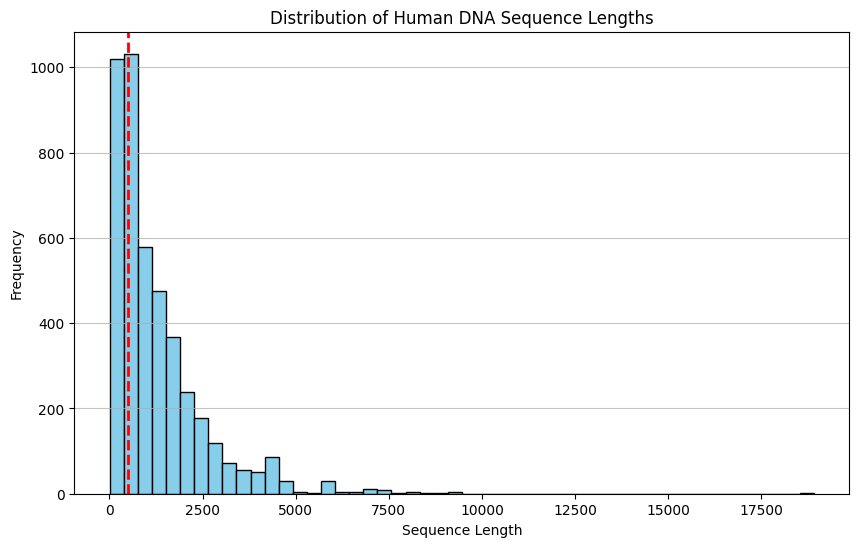

In [ ]:
import matplotlib.pyplot as plt

human_df['sequence_length'] = human_df['sequence'].apply(len)

plt.figure(figsize=(10, 6))
plt.hist(human_df['sequence_length'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Human DNA Sequence Lengths')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.axvline(500, color='red', linestyle='dashed', linewidth=2, label='Mean')

plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
human_df = human_df[human_df['sequence_length'] <= 500]

print("DataFrame filtered by sequence length (<= 500).")
print(human_df.head())
print(human_df.shape)

DataFrame filtered by sequence length (<= 500).
                                             sequence  label  sequence_length  \
0   ATGCCCCAACTAAATACTACCGTATGGCCCACCATAATTACCCCCA...      4              207   
10  ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...      3              487   
11  ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...      3              356   
12  ATGAAGATTGCACACAGAGGTCCAGATGCATTCCGTTTTGAGAATG...      3              189   
13  ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...      3               98   

                                                kmers  \
0   ['ATGCCC', 'TGCCCC', 'GCCCCA', 'CCCCAA', 'CCCA...   
10  ['ATGTGT', 'TGTGTG', 'GTGTGG', 'TGTGGC', 'GTGG...   
11  ['ATGTGT', 'TGTGTG', 'GTGTGG', 'TGTGGC', 'GTGG...   
12  ['ATGAAG', 'TGAAGA', 'GAAGAT', 'AAGATT', 'AGAT...   
13  ['ATGTGT', 'TGTGTG', 'GTGTGG', 'TGTGGC', 'GTGG...   

                                            kmers_str  
0   ATGCCC TGCCCC GCCCCA CCCCAA CCCAAC CCAACT CAAC...  
10  ATGTGT

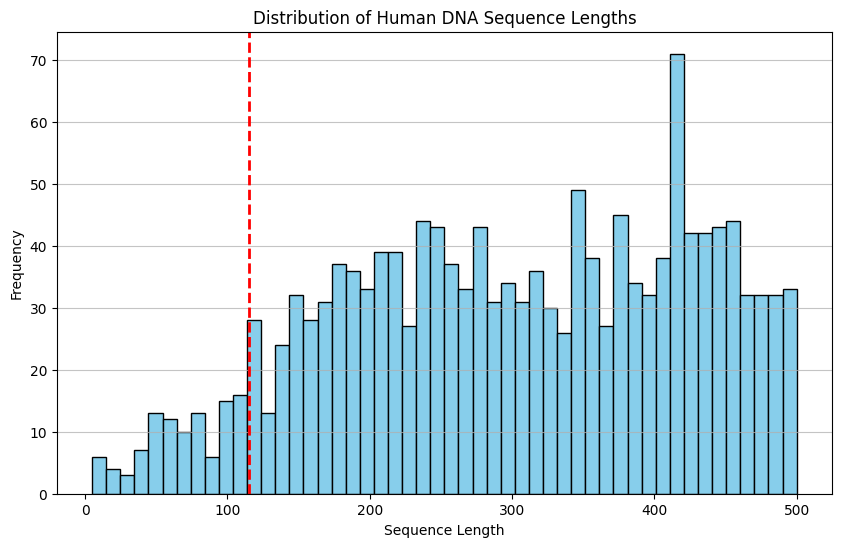

In [ ]:
human_df['sequence_length'] = human_df['sequence'].apply(len)

plt.figure(figsize=(10, 6))
plt.hist(human_df['sequence_length'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Human DNA Sequence Lengths')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.axvline(115, color='red', linestyle='dashed', linewidth=2, label='Mean')

plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
human_df = human_df[human_df['sequence_length'] >= 115]

print("DataFrame filtered by sequence length (<= 500).")
print(human_df.head())
print(human_df.shape)

DataFrame filtered by sequence length (<= 500).
                                             sequence  label  sequence_length  \
0   ATGCCCCAACTAAATACTACCGTATGGCCCACCATAATTACCCCCA...      4              207   
10  ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...      3              487   
11  ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...      3              356   
12  ATGAAGATTGCACACAGAGGTCCAGATGCATTCCGTTTTGAGAATG...      3              189   
24  GCCACCACAGGCCTGAAGATGAAGCACCTCCTTACTGGGCAAGAGA...      2              387   

                                                kmers  \
0   ['ATGCCC', 'TGCCCC', 'GCCCCA', 'CCCCAA', 'CCCA...   
10  ['ATGTGT', 'TGTGTG', 'GTGTGG', 'TGTGGC', 'GTGG...   
11  ['ATGTGT', 'TGTGTG', 'GTGTGG', 'TGTGGC', 'GTGG...   
12  ['ATGAAG', 'TGAAGA', 'GAAGAT', 'AAGATT', 'AGAT...   
24  ['GCCACC', 'CCACCA', 'CACCAC', 'ACCACA', 'CCAC...   

                                            kmers_str  
0   ATGCCC TGCCCC GCCCCA CCCCAA CCCAAC CCAACT CAAC...  
10  ATGTGT

/tmp/ipython-input-4001678808.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=human_df, palette='coolwarm')


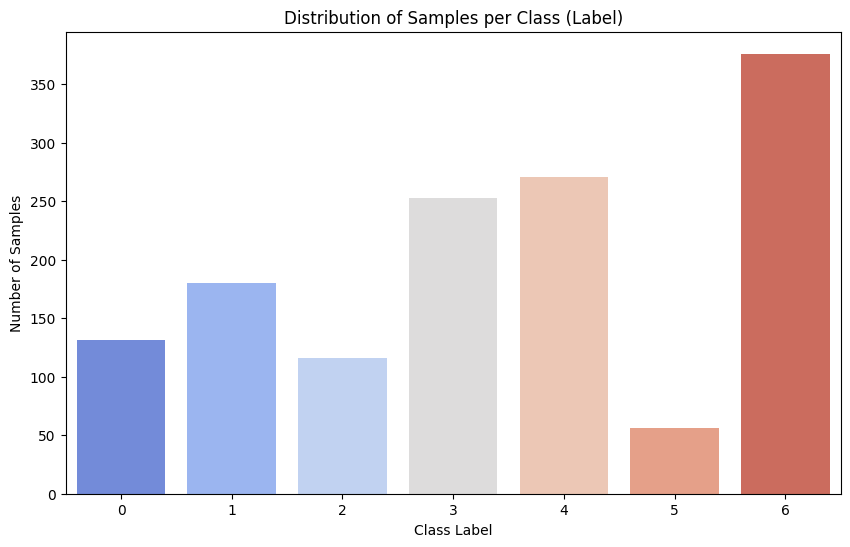

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(x='label', data=human_df, palette='coolwarm')
plt.title('Distribution of Samples per Class (Label)')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.show()

For a DNA sequence of length \(L\), the total number of overlapping \(k\)-mers is given by the formula \(L-k+1\). The relationship between the length of the \(k\)-mer (\(k\)) and the total number of k-mers is straightforward: as \(k\) increases, the total number of possible \(k\)-mers decreases.

In [ ]:
def get_kmers(sequence, k=3):
    """Split a DNA sequence into overlapping k-mers."""
    return [sequence[i:i+k] for i in range(len(sequence) - k + 1)]


In [ ]:
k = 6
human_df["kmers"] = human_df["sequence"].apply(lambda x: get_kmers(x, k))


In [ ]:
human_df["kmers_str"] = human_df["kmers"].apply(lambda x: " ".join(x))


In [ ]:
human_df.head(5)

,sequence,label,sequence_length,kmers,kmers_str
0,ATGCCCCAACTAAATACTACCGTATGGCCCACCATAATTACCCCCA...,4,207,"[ATGCCC, TGCCCC, GCCCCA, CCCCAA, CCCAAC, CCAAC...",ATGCCC TGCCCC GCCCCA CCCCAA CCCAAC CCAACT CAAC...
10,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3,487,"[ATGTGT, TGTGTG, GTGTGG, TGTGGC, GTGGCA, TGGCA...",ATGTGT TGTGTG GTGTGG TGTGGC GTGGCA TGGCAT GGCA...
11,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3,356,"[ATGTGT, TGTGTG, GTGTGG, TGTGGC, GTGGCA, TGGCA...",ATGTGT TGTGTG GTGTGG TGTGGC GTGGCA TGGCAT GGCA...
12,ATGAAGATTGCACACAGAGGTCCAGATGCATTCCGTTTTGAGAATG...,3,189,"[ATGAAG, TGAAGA, GAAGAT, AAGATT, AGATTG, GATTG...",ATGAAG TGAAGA GAAGAT AAGATT AGATTG GATTGC ATTG...
24,GCCACCACAGGCCTGAAGATGAAGCACCTCCTTACTGGGCAAGAGA...,2,387,"[GCCACC, CCACCA, CACCAC, ACCACA, CCACAG, CACAG...",GCCACC CCACCA CACCAC ACCACA CCACAG CACAGG ACAG...


In [ ]:
# from google.colab import drive
# import os

# drive.mount('/content/drive')

# output_dir = '/content/drive/My Drive/DNA_Dataset'
# output_filename = 'human_dna_data.csv'
# output_path = os.path.join(output_dir, output_filename)

# os.makedirs(output_dir, exist_ok=True)

# human_df.to_csv(output_path, index=False)

# print(f"DataFrame saved to: {output_path}")

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [ ]:

train_df, temp_df = train_test_split(human_df, test_size=0.2, random_state=42, stratify=human_df["label"])

val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df["label"])

print(len(train_df), len(val_df), len(test_df))


1106 138 139


In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_df["kmers_str"])


In [ ]:
X_train = tokenizer.texts_to_sequences(train_df["kmers_str"])
X_val = tokenizer.texts_to_sequences(val_df["kmers_str"])
X_test = tokenizer.texts_to_sequences(test_df["kmers_str"])


In [ ]:
max_len = max(len(seq) for seq in X_train)

X_train = pad_sequences(X_train, maxlen=max_len, padding='post')
X_val   = pad_sequences(X_val,   maxlen=max_len, padding='post')
X_test  = pad_sequences(X_test,  maxlen=max_len, padding='post')


In [ ]:
y_train = train_df["label"].astype(int).values
y_val   = val_df["label"].astype(int).values
y_test  = test_df["label"].astype(int).values


In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.layers import Embedding
from keras.layers import LSTM
from keras.layers import BatchNormalization

In [ ]:
from tensorflow.keras.optimizers import Adam



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, BatchNormalization, Bidirectional, LeakyReLU
from tensorflow.keras.optimizers import Adam

def create_lstm_model(embedding_size, max_words, input_shape, n_classes):
    model = Sequential()

    # Embedding Layer
    model.add(Embedding(
        input_dim=max_words,
        output_dim=embedding_size,
        input_shape=(input_shape,),
        mask_zero=True
    ))

    # Bidirectional LSTM Layer
    model.add(Bidirectional(
        LSTM(128, dropout=0.2, recurrent_dropout=0.25, return_sequences=False)
    ))
    model.add(Dropout(0.1))

    # Dense Layers with LeakyReLU
    model.add(Dense(128))
    model.add(LeakyReLU(alpha=0.15))  # You can adjust alpha as needed
    model.add(BatchNormalization())
    model.add(Dropout(0.1))

    # Output Layer for multiclass classification
    model.add(Dense(n_classes, activation='softmax'))

    # Compile with custom learning rate
    model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=0.005),
        metrics=['accuracy']
    )

    return model

In [ ]:
from tensorflow.keras.utils import to_categorical

n_classes = len(set(y_train))  # e.g. 5
y_train_cat = to_categorical(y_train, num_classes=n_classes)
y_val_cat   = to_categorical(y_val, num_classes=n_classes)

model = create_lstm_model(
    embedding_size=128,
    max_words=len(tokenizer.word_index) + 1,
    input_shape=X_train.shape[1],
    n_classes=n_classes
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 495, 128)       │       545,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 843,015 (3.22 MB)

 Trainable params: 842,759 (3.21 MB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))

print("Class weights loaded successfully.")
print(class_weights_dict)

Class weights loaded successfully.
{0: np.float64(1.5047619047619047), 1: np.float64(1.0972222222222223), 2: np.float64(1.6989247311827957), 3: np.float64(0.7821782178217822), 4: np.float64(0.728110599078341), 5: np.float64(3.511111111111111), 6: np.float64(0.5266666666666666)}


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=10,
    batch_size=16,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 252s 3s/step - accuracy: 0.3015 - loss: 1.8113 - val_accuracy: 0.6812 - val_loss: 1.6053
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 260s 3s/step - accuracy: 0.8248 - loss: 0.4669 - val_accuracy: 0.6812 - val_loss: 1.1135
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 243s 3s/step - accuracy: 0.8604 - loss: 0.3315 - val_accuracy: 0.7174 - val_loss: 0.9560
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 260s 3s/step - accuracy: 0.9314 - loss: 0.2071 - val_accuracy: 0.6667 - val_loss: 1.2982
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 262s 3s/step - accuracy: 0.9643 - loss: 0.1141 - val_accuracy: 0.6739 - val_loss: 1.5416
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 240s 3s/step - accuracy: 0.9584 - loss: 0.1156 - val_accuracy: 0.7174 - val_loss: 1.7480


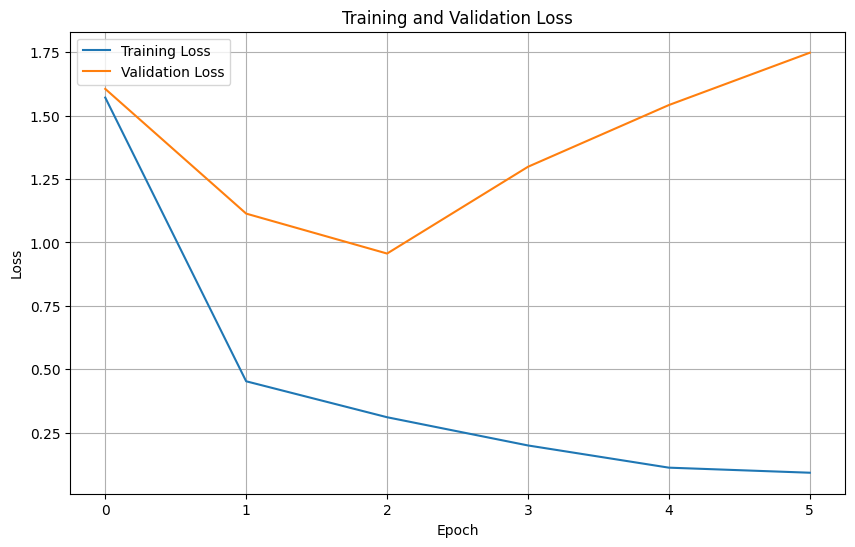

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 696ms/step
Test Accuracy: 0.6691


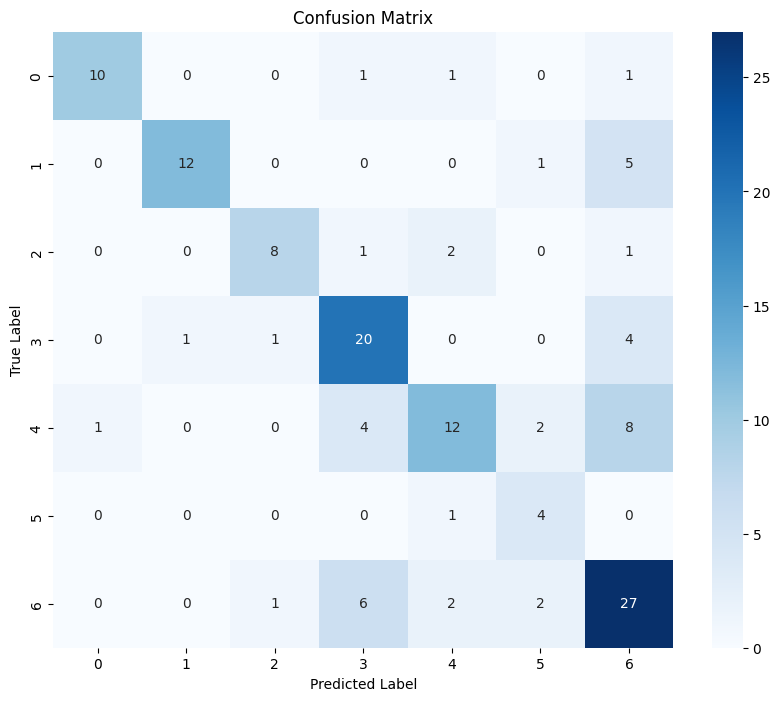

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predict the classes for the test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_classes)
print(f"Test Accuracy: {accuracy:.4f}")

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()